In [1]:
#!pip install xarray netCDF4 dask geopandas regionmask -q

In [2]:
# Import required libraries
import numpy as np
import geopandas as gpd
import xarray as xr
import dask
import dask.array as da
import matplotlib.pyplot as plt
from scipy.stats import linregress

from dask.distributed import Client as DaskClient
from shapely.geometry import box

In [3]:
# Path to the main .shp file
shapefile_path = "C:/Users/146761/Desktop/DCCEEW-task/Region/LocalLandServices_boundaries/LLS_Layer.shp"

# Read the shapefile
gdf = gpd.read_file(shapefile_path)

# Display the first rows of the attribute table
display(gdf.head())

##### Or use the code below if using google Colab

# from google.colab import files

# uploaded = files.upload()
# # Convert to standard geographic coordinates
# gdf = gpd.read_file("NSW.geojson")

# gdf = gdf.to_crs("EPSG:4326")

# # Display basic information
# print(gdf.crs)
# print(gdf.total_bounds)

# gdf.head()

,OBJECTID_1,LLS,SHAPE_LENG,SHAPE_AREA,SHAPE_LEN,geometry
0,1,Central Tablelands,15.996444,0.0,0.0,"POLYGON ((149.79566 -32.05809, 149.79246 -32.0..."
1,2,Greater Sydney,8.501700,0.0,0.0,"POLYGON ((151.63129 -33.17712, 151.63121 -33.1..."
2,3,Hunter,13.102923,0.0,0.0,"POLYGON ((152.80431 -31.72809, 152.8043 -31.72..."
3,4,North Coast,14.112756,0.0,0.0,"POLYGON ((152.80431 -31.72809, 152.80426 -31.7..."
4,5,North West,21.198913,0.0,0.0,"POLYGON ((150.48344 -28.66213, 150.48458 -28.6..."


In [4]:
# Select only Central Tablelands
central_tablelands = gdf[gdf["LLS"].str.strip().str.lower() == "central tablelands"].copy()

# Print the attribute information
print(central_tablelands.drop(columns="geometry").to_string(index=False))
# Coordinate reference system
print("CRS:", central_tablelands.crs)

 OBJECTID_1                LLS  SHAPE_LENG  SHAPE_AREA  SHAPE_LEN
          1 Central Tablelands   15.996444         0.0        0.0
CRS: EPSG:4283


Minimum longitude: 148.2902
Maximum longitude: 150.6198
Minimum latitude:  -34.2059
Maximum latitude:  -32.0581


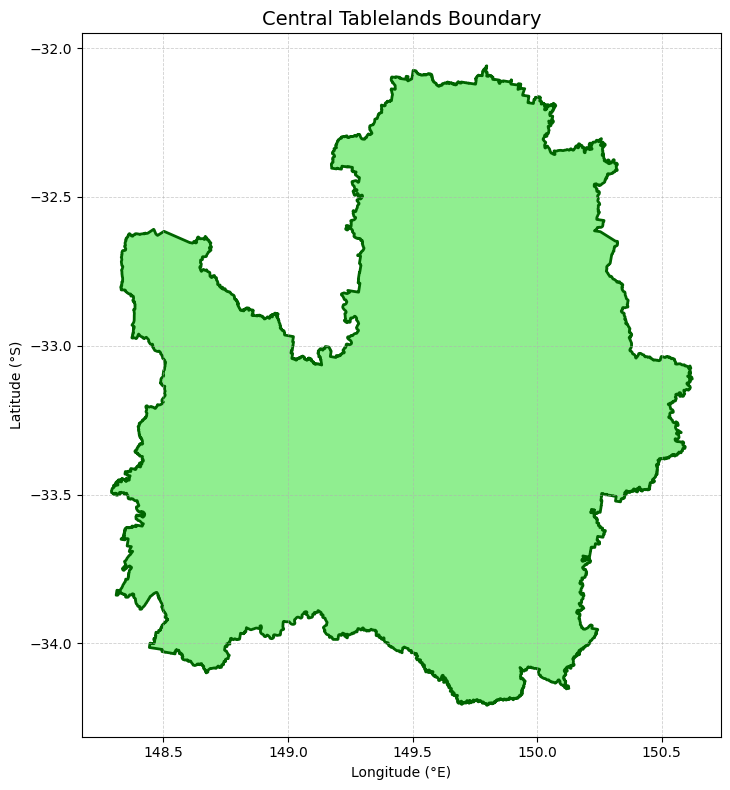

In [5]:
# Convert to longitude/latitude coordinates
gdf = gdf.to_crs("EPSG:4326")

# Select Central Tablelands
central_tablelands = gdf[gdf["LLS"].str.strip().str.lower() == "central tablelands"].copy()

# Get bounding box
min_lon, min_lat, max_lon, max_lat = central_tablelands.total_bounds

print(f"Minimum longitude: {min_lon:.4f}")
print(f"Maximum longitude: {max_lon:.4f}")
print(f"Minimum latitude:  {min_lat:.4f}")
print(f"Maximum latitude:  {max_lat:.4f}")

# Quick visual check
fig, ax = plt.subplots(figsize=(9, 8))

central_tablelands.plot(ax=ax,facecolor="lightgreen",edgecolor="darkgreen",linewidth=2)

# Add coordinate grid
ax.grid(visible=True,linestyle="--",linewidth=0.6,alpha=0.6)

ax.set_title("Central Tablelands Boundary", fontsize=14)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")

plt.tight_layout()
plt.show()

In [6]:
# Combine all geometries into one region.
# This makes creation of a single regional mask simpler and slightly more efficient.

central_region = central_tablelands[["geometry"]].dissolve()

central_region

,geometry
0,"POLYGON ((149.79566 -32.05809, 149.79246 -32.0..."


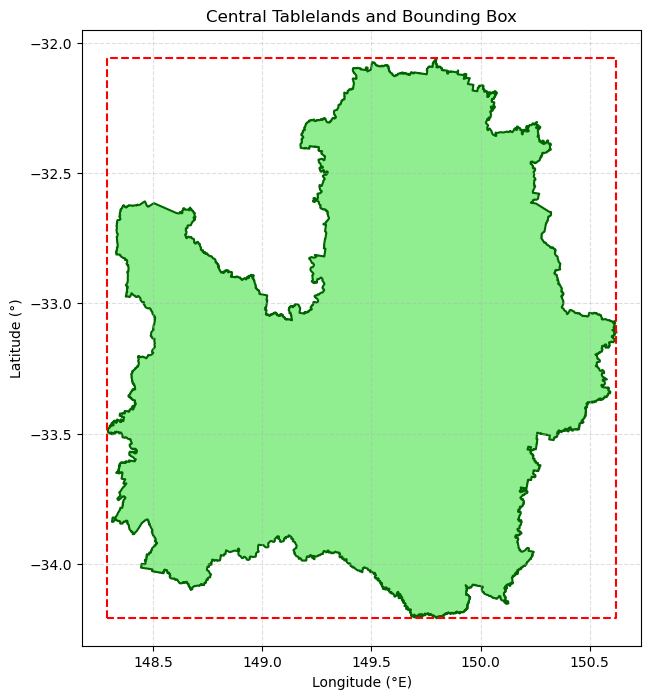

In [7]:
# Map the region and its rectangular bounding box

bbox_geometry = box(min_lon,min_lat,max_lon,max_lat)

bbox_gdf = gpd.GeoDataFrame({"name": ["Central Tablelands bounding box"]},geometry=[bbox_geometry],crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(9, 8))

central_tablelands.plot(ax=ax,facecolor="lightgreen",edgecolor="darkgreen",linewidth=1.5)

bbox_gdf.boundary.plot(ax=ax,color="red",linestyle="--",linewidth=1.5)

ax.set_title("Central Tablelands and Bounding Box")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°)")
ax.grid(linestyle="--", alpha=0.4)

plt.show()

In [8]:
# Build annual NARCliM rainfall URLs: 2010-2020

base_url = (
    "https://thredds.nci.org.au/thredds/dodsC/"
    "zz63/NARCliM2-0/output-CMIP6/DD/"
    "NARCliM2-0-SEAus-04/"
    "NSW-Government/ERA5/evaluation/r1i1p1f1/"
    "NARCliM2-0-WRF412R3/v1-r1/day/pr/latest"
)

# Years to process
years = range(2010, 2021)

# Build one URL for each year
file_list = [
    (
        f"{base_url}/"
        f"pr_NARCliM2-0-SEAus-04_ERA5_evaluation_r1i1p1f1_"
        f"NSW-Government_NARCliM2-0-WRF412R3_v1-r1_day_"
        f"{year}0101-{year}1231.nc"
    )
    for year in years
]

print("Number of files:", len(file_list))

print("\nFirst file:")
print(file_list[0])

print("\nLast file:")
print(file_list[-1])

Number of files: 11

First file:
https://thredds.nci.org.au/thredds/dodsC/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ERA5/evaluation/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day/pr/latest/pr_NARCliM2-0-SEAus-04_ERA5_evaluation_r1i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1_day_20100101-20101231.nc

Last file:
https://thredds.nci.org.au/thredds/dodsC/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ERA5/evaluation/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day/pr/latest/pr_NARCliM2-0-SEAus-04_ERA5_evaluation_r1i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1_day_20200101-20201231.nc


In [9]:
# Open one NARCliM file and inspect its structure

test_ds = xr.open_dataset(file_list[0],engine="netcdf4")

print(test_ds)

print("\nDimensions:")
print(test_ds.sizes)

print("\nRainfall dimensions:")
print(test_ds["pr"].dims)

print("\nLatitude dimensions:")
print(test_ds["lat"].dims)

print("\nLongitude dimensions:")
print(test_ds["lon"].dims)

print("\nRainfall units:")
print(test_ds["pr"].attrs.get("units"))

<xarray.Dataset> Size: 428MB
Dimensions:    (rlon: 599, rlat: 484, time: 365, bnds: 2, crs: 1)
Coordinates:
  * rlon       (rlon) float64 5kB -179.7 -179.6 -179.6 ... 179.6 179.7 179.7
  * rlat       (rlat) float64 4kB -10.46 -10.43 -10.39 ... 6.468 6.504 6.539
    time_bnds  (time, bnds) datetime64[ns] 6kB ...
  * time       (time) datetime64[ns] 3kB 2010-01-01T12:00:00 ... 2010-12-31T1...
  * crs        (crs) int32 4B 0
    lat        (rlat, rlon) float64 2MB ...
    lon        (rlat, rlon) float64 2MB ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, rlat, rlon) float32 423MB ...
Attributes: (12/43)
    project_id:                      CORDEX
    comment:                         DPIE version of WRF4.1.2
    DPIE_WRF_HASH:                   a051fdc73749349fd244ce8e596088a372bdb0c5
    wrf_options:                     sst_update & tmn_update
    frequency:                       day
    git_url_postprocessing:          git@bitbucket:oehcas/cordex_postproces

In [10]:
# Identify NARCliM grid-cell centres inside the bounding box

# Extract 2D latitude and longitude arrays
lat = test_ds["lat"].values
lon = test_ds["lon"].values

# Find grid-cell centres inside the bounding box
inside_bbox = ((lon >= min_lon) & (lon <= max_lon) & (lat >= min_lat) & (lat <= max_lat))

# Count the number of selected grid cells
n_cells = inside_bbox.sum()

print("Number of NARCliM grid cells inside bounding box:")
print(n_cells)

Number of NARCliM grid cells inside bounding box:
3398


In [11]:
# Get rlat and rlon indices for the selected region

# Rows containing at least one grid-cell centre inside the bbox
rlat_idx = np.where(inside_bbox.any(axis=1))[0]

# Columns containing at least one grid-cell centre inside the bbox
rlon_idx = np.where(inside_bbox.any(axis=0))[0]

# Create continuous slices
rlat_slice = slice(rlat_idx.min(),rlat_idx.max() + 1)

rlon_slice = slice(rlon_idx.min(),rlon_idx.max() + 1)

print("rlat index range:")
print(rlat_idx.min(), "to", rlat_idx.max())

print("\nrlon index range:")
print(rlon_idx.min(), "to", rlon_idx.max())

# Test crop
test_crop = test_ds.isel(rlat=rlat_slice,rlon=rlon_slice)

print("\nOriginal dataset size:")
print(test_ds.sizes)

print("\nCropped dataset size:")
print(test_crop.sizes)

rlat index range:
169 to 229

rlon index range:
335 to 391

Original dataset size:
Frozen({'rlon': 599, 'rlat': 484, 'time': 365, 'bnds': 2, 'crs': 1})

Cropped dataset size:
Frozen({'rlon': 57, 'rlat': 61, 'time': 365, 'bnds': 2, 'crs': 1})


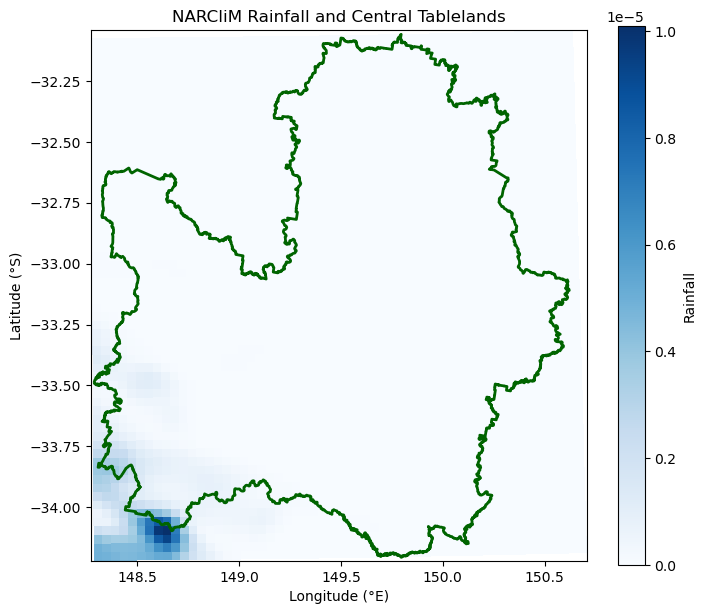

In [12]:
# Plot NARCliM rainfall using TRUE longitude and latitude and overlay boundary

fig, ax = plt.subplots(figsize=(8, 7))

# Plot rainfall using geographic lon/lat coordinates
test_crop["pr"].isel(time=0).plot(ax=ax,x="lon",y="lat",cmap="Blues",cbar_kwargs={"label": "Rainfall"})

# Overlay the boundary of region
central_tablelands.boundary.plot(ax=ax,edgecolor="darkgreen",linewidth=2)

ax.set_title("NARCliM Rainfall and Central Tablelands")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")

plt.show()

In [13]:
# Function to select the same grid cells from every year

def select_bbox_region(ds):
    """
    Select the NARCliM grid section corresponding to the
    Central Tablelands bounding box.
    """
    return ds.isel(
        rlat=rlat_slice,
        rlon=rlon_slice
    )

In [14]:
# Open, crop and stack all annual files: 2010-2020

# Close the test dataset first
test_ds.close()

ds = xr.open_mfdataset(
    file_list,
    # Read remote NetCDF files
    engine="netcdf4",
    # Crop every annual file before combining
    preprocess=select_bbox_region,
    # Combine files based on their time coordinates
    combine="by_coords",
    # Use Dask for parallel processing
    parallel=True,
    # Keep approximately one year per time chunk
    chunks={"time": 365}
)

print(ds)
print("\nDataset dimensions:")
print(ds.sizes)

print("\nTime range:")
print(ds.time.min().values)
print(ds.time.max().values)

print("\nNumber of daily observations:")
print(ds.sizes["time"])

<xarray.Dataset> Size: 56MB
Dimensions:    (time: 4018, rlat: 61, rlon: 57, bnds: 2, crs: 1)
Coordinates:
  * rlon       (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat       (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
    time_bnds  (time, bnds) datetime64[ns] 64kB dask.array<chunksize=(365, 2), meta=np.ndarray>
  * time       (time) datetime64[ns] 32kB 2010-01-01T12:00:00 ... 2020-12-31T...
  * crs        (crs) int32 4B 0
    lat        (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon        (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    pr         (time, rlat, rlon) float32 56MB dask.array<chunksize=(365, 61, 57), meta=np.ndarray>
Attributes: (12/43)
    project_id:                      CORDEX
    comment:                         DPIE version of WRF4.1.2
    DPIE_WRF_HASH:                   a051fdc73749349fd244ce8e59608

In [15]:
# Keep only grid-cell centres inside the geographic bbox

# Create a 2D condition using the cropped grid coordinates
bbox_condition = ((ds["lon"] >= min_lon) & (ds["lon"] <= max_lon) & (ds["lat"] >= min_lat) & (ds["lat"] <= max_lat))

# Extract precipitation
pr = ds["pr"]

# Keep only pixels whose centres fall inside the bounding box
pr = pr.where(bbox_condition)

print(pr)

print("\nNumber of valid grid cells:")
print(int(bbox_condition.sum().compute()))

<xarray.DataArray 'pr' (time: 4018, rlat: 61, rlon: 57)> Size: 56MB
dask.array<where, shape=(4018, 61, 57), dtype=float32, chunksize=(365, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
  * time     (time) datetime64[ns] 32kB 2010-01-01T12:00:00 ... 2020-12-31T12...
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
Attributes:
    cell_methods:   time: mean
    units:          kg m-2 s-1
    long_name:      Precipitation
    standard_name:  precipitation_flux
    MD5:            9b9d199aa82e0d7d2acbfac214338c89
    grid_mapping:   crs
    _ChunkSizes:    [  1 484 599]

Number of valid grid cells:
3398


In [16]:
# Convert rainfall to mm/day. The NARCliM precipitation variable pr is in kg m⁻² s⁻¹ (precipitation flux rate)

# 1 kg m-2 of water = 1 mm
# 86400 seconds = 1 day

pr_mm = pr * 86400

# Update metadata
pr_mm.name = "precipitation"

pr_mm.attrs["units"] = "mm/day"

pr_mm.attrs["long_name"] = ("Daily precipitation")

print(pr_mm)

<xarray.DataArray 'precipitation' (time: 4018, rlat: 61, rlon: 57)> Size: 56MB
dask.array<mul, shape=(4018, 61, 57), dtype=float32, chunksize=(365, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
  * time     (time) datetime64[ns] 32kB 2010-01-01T12:00:00 ... 2020-12-31T12...
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
Attributes:
    units:      mm/day
    long_name:  Daily precipitation


In [17]:
# Quality Assurance / Quality Control (QA/QC)

print("========== BASIC DATA INFORMATION ==========")

# Dimensions and time coverage
print("\nDimensions:")
print(pr_mm.sizes)

print("\nTime period:")
print(pr_mm.time.min().values,"to",pr_mm.time.max().values)

print("\nNumber of daily observations:")
print(pr_mm.sizes["time"])

print("\nRainfall units:")
print(pr_mm.attrs.get("units"))

# Check for duplicate timestamps

time_values = pr_mm.time.values

n_duplicates = len(time_values) - len(np.unique(time_values))

print("\n========== TIME CHECK ==========")

print("Duplicate timestamps:")
print(n_duplicates)

# Check for missing rainfall values

missing_count = pr_mm.isnull().sum().compute()

total_count = pr_mm.size

missing_percent = (float(missing_count) / total_count) * 100

print("\n========== MISSING DATA CHECK ==========")

print("Number of missing values:")
print(int(missing_count))

print(f"Missing values (%): {missing_percent:.3f}")

# Check minimum and maximum rainfall

rain_min = float(pr_mm.min().compute())
rain_max = float(pr_mm.max().compute())

print("\n========== VALUE RANGE CHECK ==========")

print(f"Minimum rainfall: {rain_min:.3f} mm/day")
print(f"Maximum rainfall: {rain_max:.3f} mm/day")

# Check for physically impossible negative rainfall

negative_count = ((pr_mm < 0).sum().compute())

print("\nNegative rainfall values:")
print(int(negative_count))

# Check number of valid spatial grid cells

# Use first day as spatial coverage is expected to be constant
valid_cells = (pr_mm.isel(time=0).notnull().sum().compute())

print("\n========== SPATIAL COVERAGE CHECK ==========")

print("Number of valid grid cells:")
print(int(valid_cells))

# Summary QA/QC result

print("\n========== QA/QC SUMMARY ==========")

if n_duplicates == 0:
    print("✓ No duplicate timestamps")
else:
    print("⚠ Duplicate timestamps detected")

if int(negative_count) == 0:
    print("✓ No negative rainfall values")
else:
    print("⚠ Negative rainfall values detected")

if missing_percent < 1:
    print("✓ Missing data are very low")
else:
    print("⚠ Missing data should be investigated")

print(f"✓ Valid spatial grid cells: {int(valid_cells)}")

========== BASIC DATA INFORMATION ==========

Dimensions:
Frozen({'time': 4018, 'rlat': 61, 'rlon': 57})

Time period:
2010-01-01T12:00:00.000000000 to 2020-12-31T12:00:00.000000000

Number of daily observations:
4018

Rainfall units:
mm/day

========== TIME CHECK ==========
Duplicate timestamps:
0

========== MISSING DATA CHECK ==========
Number of missing values:
317422
Missing values (%): 2.272

========== VALUE RANGE CHECK ==========
Minimum rainfall: 0.000 mm/day
Maximum rainfall: 205.642 mm/day

Negative rainfall values:
0

========== SPATIAL COVERAGE CHECK ==========
Number of valid grid cells:
3398

========== QA/QC SUMMARY ==========
✓ No duplicate timestamps
✓ No negative rainfall values
⚠ Missing data should be investigated
✓ Valid spatial grid cells: 3398


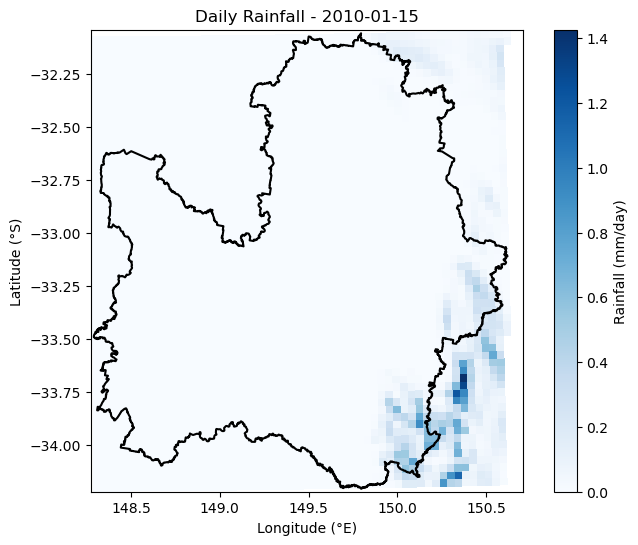

In [18]:
# Plot one selected rainfall day using true longitude and latitude

date_to_plot = "2010-01-15"

fig, ax = plt.subplots(figsize=(8, 6))

# Plot rainfall using geographic lon/lat coordinates
pr_mm.sel(time=date_to_plot).plot(ax=ax,x="lon",y="lat",cmap="Blues",cbar_kwargs={"label": "Rainfall (mm/day)"})

# Overlay the region boundary
central_tablelands.boundary.plot(ax=ax,edgecolor="black",linewidth=1.5)

ax.set_title(f"Daily Rainfall - {date_to_plot}")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")

plt.show()

In [19]:
# Create final processed rainfall xarray with time, latitude and longitude coordinates

# Create final rainfall DataArray
pr_ready = pr_mm.copy()

# Give the variable a clear name
pr_ready.name = "rainfall"

# Make sure true latitude and longitude are included
pr_ready = pr_ready.assign_coords(lat=ds["lat"],lon=ds["lon"])

# Add useful metadata
pr_ready.attrs["units"] = "mm/day"
pr_ready.attrs["long_name"] = "Daily rainfall"
pr_ready.attrs["region"] = "Central Tablelands"
pr_ready.attrs["period"] = (
    f"{int(pr_ready.time.dt.year.min())}-"
    f"{int(pr_ready.time.dt.year.max())}"
)
pr_ready.attrs["spatial_selection"] = ("Grid-cell centres within the region bounding box")

# Display final xarray
print(pr_ready)

<xarray.DataArray 'rainfall' (time: 4018, rlat: 61, rlon: 57)> Size: 56MB
dask.array<mul, shape=(4018, 61, 57), dtype=float32, chunksize=(365, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
  * time     (time) datetime64[ns] 32kB 2010-01-01T12:00:00 ... 2020-12-31T12...
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
Attributes:
    units:              mm/day
    long_name:          Daily rainfall
    region:             Central Tablelands
    period:             2010-2020
    spatial_selection:  Grid-cell centres within the region bounding box


In [20]:
# Calculate regional daily mean rainfall

# Average rainfall across all grid cells
daily_regional_rainfall = pr_ready.mean(dim=["rlat", "rlon"],skipna=True)

daily_regional_rainfall.name = "rainfall"

print(daily_regional_rainfall)

<xarray.DataArray 'rainfall' (time: 4018)> Size: 16kB
dask.array<mean_agg-aggregate, shape=(4018,), dtype=float32, chunksize=(365,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 32kB 2010-01-01T12:00:00 ... 2020-12-31T12...


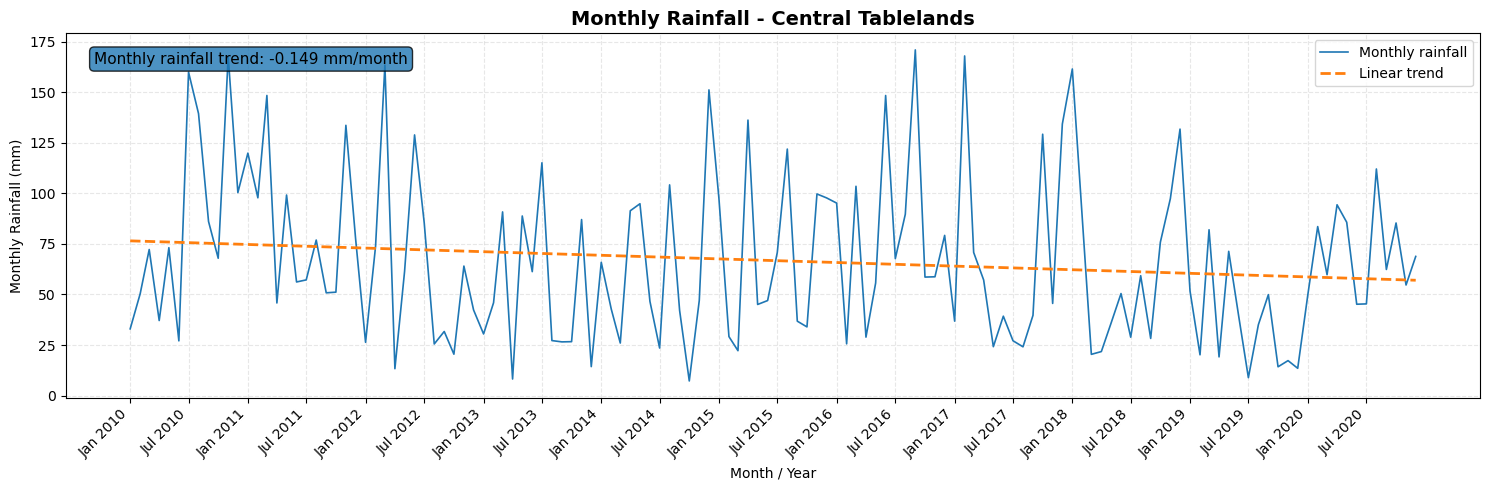

In [21]:
# Calculate and plot monthly rainfall totals with linear trend

# Sum daily regional rainfall within each month
monthly_rainfall = daily_regional_rainfall.resample(time="MS").sum()

monthly_rainfall.name = "monthly_rainfall"
monthly_rainfall.attrs["units"] = "mm/month"

# Calculate linear trend

# Convert rainfall values to NumPy
rain_values = monthly_rainfall.values

# Simple numeric time index
x = np.arange(len(rain_values))

# Fit linear trend
slope, intercept = np.polyfit(x,rain_values,1)

trend = slope * x + intercept

# Plot monthly rainfall

fig, ax = plt.subplots(figsize=(15, 5))

# Monthly rainfall
ax.plot(monthly_rainfall.time.values,rain_values,linewidth=1.2,label="Monthly rainfall")

# Linear trend
ax.plot(monthly_rainfall.time.values,trend,linestyle="--",linewidth=2,label="Linear trend")

# Add trend value inside the plot
ax.text(0.02, 0.95, f"Monthly rainfall trend: {slope:.3f} mm/month", transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.8))

# Add month labels

label_times = monthly_rainfall.time.where(monthly_rainfall.time.dt.month.isin([1, 7]),drop=True)

ax.set_xticks(label_times.values)

ax.set_xticklabels([date.strftime("%b %Y") for date in label_times.to_index()], rotation=45, ha="right")

# Figure formatting

ax.set_title("Monthly Rainfall - Central Tablelands",fontsize=14,fontweight="bold")

ax.set_xlabel("Month / Year")
ax.set_ylabel("Monthly Rainfall (mm)")

ax.legend()

ax.grid(True,linestyle="--",alpha=0.3)

plt.tight_layout()
plt.show()


# # Print trend
# print(f"Monthly rainfall trend: {slope:.3f} mm/month")

<xarray.DataArray 'rainfall' (time: 45)> Size: 180B
dask.array<stack, shape=(45,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 360B 2010-02-28 2010-05-31 ... 2021-02-28
    season   (time) <U6 1kB 'Summer' 'Autumn' 'Winter' ... 'Spring' 'Summer'
Attributes:
    units:    mm/season


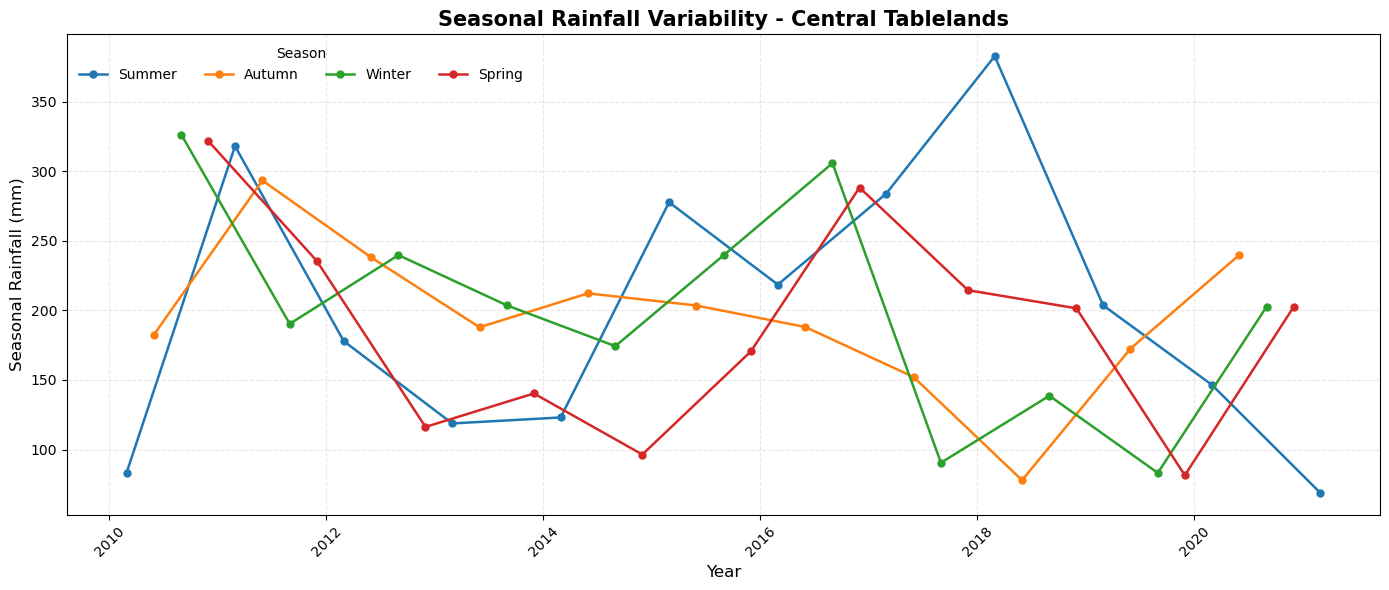

In [22]:
# Calculate seasonal rainfall totals
# DJF = Summer
# MAM = Autumn
# JJA = Winter
# SON = Spring

seasonal_rainfall = daily_regional_rainfall.resample(time="QE-FEB").sum()

seasonal_rainfall.attrs["units"] = "mm/season"

# Assign season names. numbers are the ending month numbers
season_map = {
    2: "Summer",
    5: "Autumn",
    8: "Winter",
    11: "Spring"
}

seasonal_rainfall = seasonal_rainfall.assign_coords(season=("time", [season_map[int(month)] for month in seasonal_rainfall.time.dt.month.values]))

print(seasonal_rainfall)

# Seasonal rainfall time series by season

fig, ax = plt.subplots(figsize=(14, 6))

for season in ["Summer", "Autumn", "Winter", "Spring"]:

    data = seasonal_rainfall.where(seasonal_rainfall["season"] == season,drop=True)
    ax.plot(data.time.values,data.values,marker="o",markersize=5,linewidth=1.8,label=season)

# Title and labels
ax.set_title("Seasonal Rainfall Variability - Central Tablelands",fontsize=15,fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Seasonal Rainfall (mm)", fontsize=12)

# Grid
ax.grid(True,linestyle="--",alpha=0.3)

# Legend
ax.legend(title="Season",ncol=4,frameon=False)

# x-axis
ax.tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()

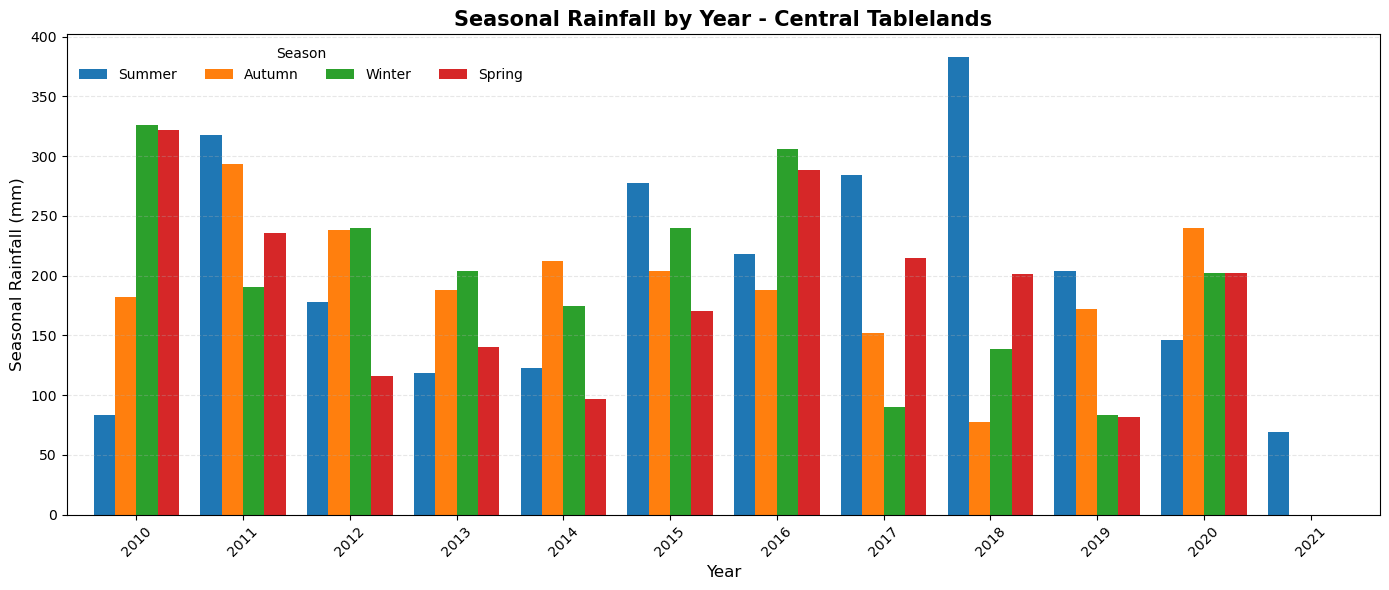

In [23]:
# Grouped bar chart of seasonal rainfall by year

# Convert seasonal rainfall to a pandas DataFrame
season_df = seasonal_rainfall.to_dataframe(name="rainfall").reset_index()

# Add year
season_df["year"] = season_df["time"].dt.year

# Pivot to year × season format
season_pivot = season_df.pivot(index="year",columns="season",values="rainfall")

# Order seasons
season_pivot = season_pivot[["Summer", "Autumn", "Winter", "Spring"]]

# Plot grouped bars
ax = season_pivot.plot(kind="bar",figsize=(14, 6),width=0.8)

ax.set_title("Seasonal Rainfall by Year - Central Tablelands",fontsize=15,fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Seasonal Rainfall (mm)", fontsize=12)

ax.legend(title="Season",ncol=4,frameon=False)

ax.grid(axis="y",linestyle="--",alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<xarray.DataArray 'annual_rainfall' (time: 11)> Size: 44B
dask.array<stack, shape=(11,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 88B 2010-01-01 2011-01-01 ... 2020-01-01
Attributes:
    units:    mm/year


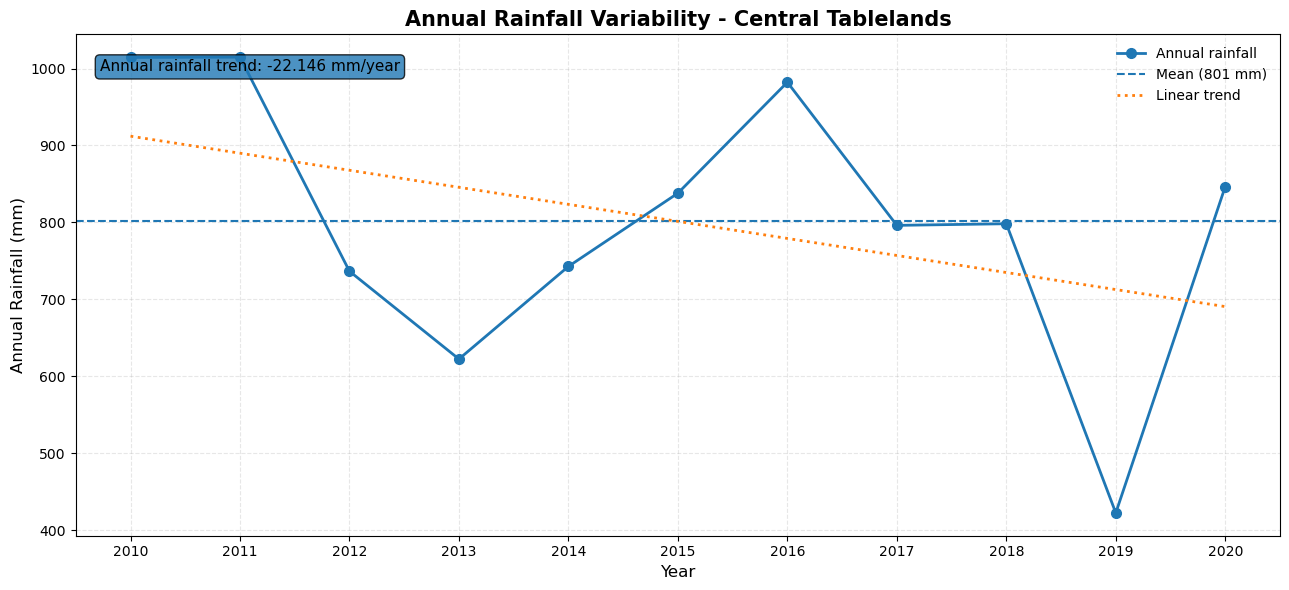

In [24]:
# Calculate annual rainfall totals

annual_rainfall = daily_regional_rainfall.resample(time="YS").sum()

annual_rainfall.name = "annual_rainfall"
annual_rainfall.attrs["units"] = "mm/year"

print(annual_rainfall)

# Plot annual rainfall with mean and trend

# Convert values for plotting/trend calculation
rain_values = annual_rainfall.values
years = annual_rainfall.time.dt.year.values

# Long-term mean annual rainfall
long_term_mean = float(annual_rainfall.mean().compute())

# Linear trend
x = np.arange(len(rain_values))

slope, intercept = np.polyfit(x,rain_values,1)

trend = slope * x + intercept

# Plot
fig, ax = plt.subplots(figsize=(13, 6))

# Annual rainfall
ax.plot(years,rain_values,marker="o",markersize=7,linewidth=2,label="Annual rainfall")

# Long-term mean
ax.axhline(long_term_mean,linestyle="--",linewidth=1.5,label=f"Mean ({long_term_mean:.0f} mm)")

# Linear trend
ax.plot(years,trend,linestyle=":",linewidth=2,label="Linear trend")

# Add trend value inside the plot
ax.text(0.02, 0.95, f"Annual rainfall trend: {slope:.3f} mm/year", transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.8))

# Formatting
ax.set_title("Annual Rainfall Variability - Central Tablelands",fontsize=15,fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Rainfall (mm)", fontsize=12)

ax.set_xticks(years)

ax.grid(True,linestyle="--",alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Print summary
#print(f"Mean annual rainfall: {long_term_mean:.1f} mm/year")

# print(
#     f"Linear trend: {slope:.2f} mm/year"
# )

In [25]:
# # Check annual rainfall against sum of monthly rainfall

# # Calculate annual rainfall by summing the monthly totals
# annual_from_monthly = monthly_rainfall.resample(
#     time="YS"
# ).sum()

# # Compare with annual rainfall calculated directly from daily data
# print("Annual rainfall from daily data:")
# print(annual_rainfall.values)

# print("\nAnnual rainfall from monthly totals:")
# print(annual_from_monthly.values)

# # Difference between the two methods
# difference = annual_rainfall - annual_from_monthly

# print("\nDifference:")
# print(difference.values)

In [26]:
# Calculate RX1day extreme rainfall index

# RX1day:
# Annual maximum 1-day precipitation amount (mm), consistent with ET-SCI climate extreme indices.

# Calculate the maximum daily rainfall within each year separately for every NARCliM grid cell
rx1day = pr_ready.resample(time="YS").max(dim="time",skipna=True)

# Add metadata
rx1day.name = "RX1day"
rx1day.attrs["units"] = "mm"
rx1day.attrs["long_name"] = ("Annual maximum 1-day precipitation")
rx1day.attrs["index"] = "RX1day"

print(rx1day)

print("\nDimensions:")
print(rx1day.sizes)

<xarray.DataArray 'RX1day' (time: 11, rlat: 61, rlon: 57)> Size: 153kB
dask.array<stack, shape=(11, 61, 57), dtype=float32, chunksize=(1, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
  * time     (time) datetime64[ns] 88B 2010-01-01 2011-01-01 ... 2020-01-01
Attributes:
    units:              mm
    long_name:          Annual maximum 1-day precipitation
    region:             Central Tablelands
    period:             2010-2020
    spatial_selection:  Grid-cell centres within the region bounding box
    index:              RX1day

Dimensions:
Frozen({'time': 11, 'rlat': 61, 'rlon': 57})


In [27]:
# Basic check of RX1day results
print("Years:")
print(rx1day.time.dt.year.values)

print("\nMinimum RX1day:")
print(float(rx1day.min().compute()),"mm")

print("\nMaximum RX1day:")
print(float(rx1day.max().compute()),"mm")

Years:
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]

Minimum RX1day:
14.993304252624512 mm

Maximum RX1day:
205.6415252685547 mm


<xarray.DataArray 'RX1day' (time: 11, rlat: 61, rlon: 57)> Size: 153kB
dask.array<stack, shape=(11, 61, 57), dtype=float32, chunksize=(1, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
  * time     (time) datetime64[ns] 88B 2010-01-01 2011-01-01 ... 2020-01-01
Attributes:
    units:              mm
    long_name:          Annual maximum 1-day precipitation
    region:             Central Tablelands
    period:             2010-2020
    spatial_selection:  Grid-cell centres within the region bounding box

Dimensions:
Frozen({'time': 11, 'rlat': 61, 'rlon': 57})

Years:
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]


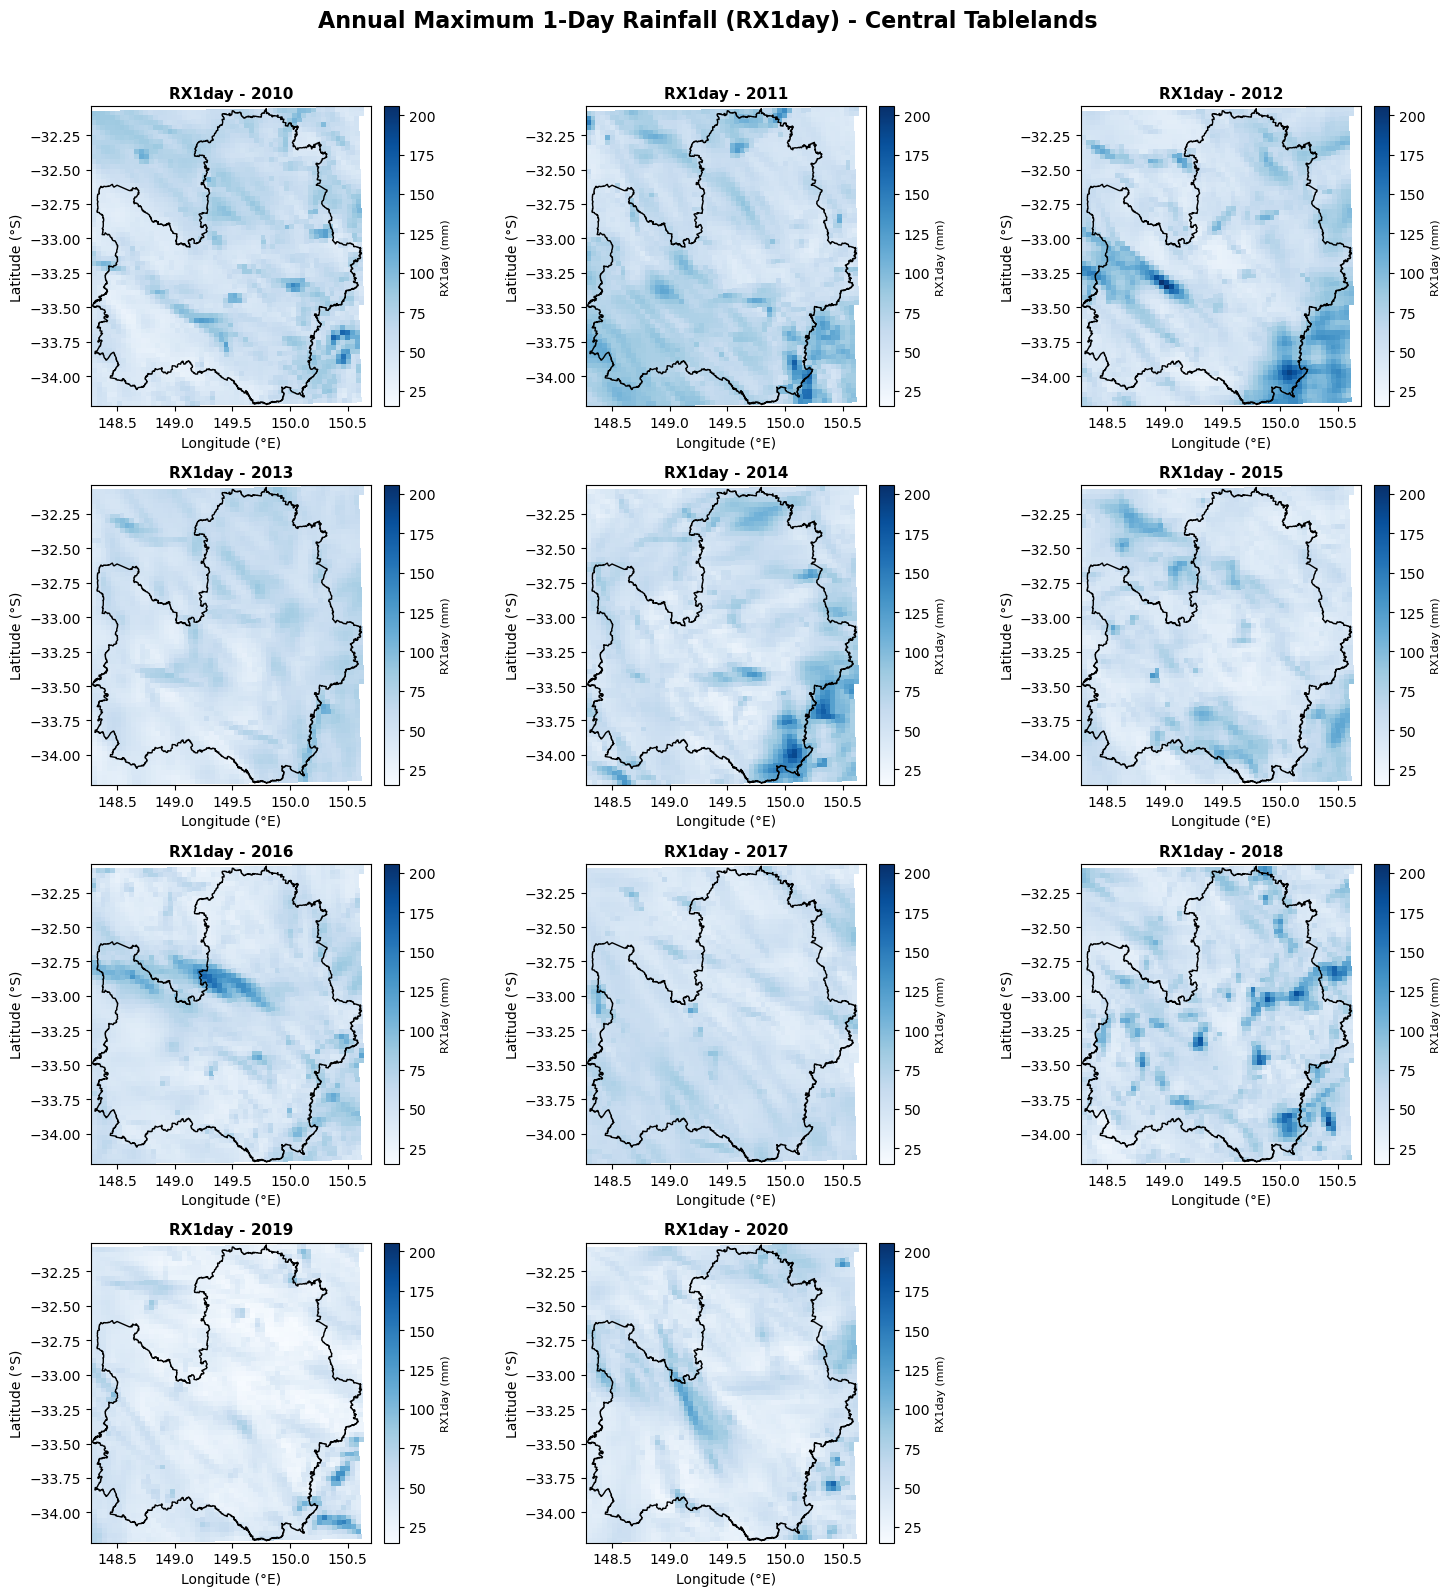

In [28]:
# Derive RX1day
# Annual maximum 1-day precipitation at each grid cell. largest daily rainfall recorded during that year (each cell shows the wettest day in that year).

rx1day = pr_ready.resample(time="YS").max(dim="time",skipna=True)

# Metadata
rx1day.name = "RX1day"
rx1day.attrs["units"] = "mm"
rx1day.attrs["long_name"] = ("Annual maximum 1-day precipitation")

print(rx1day)

print("\nDimensions:")
print(rx1day.sizes)

print("\nYears:")
print(rx1day.time.dt.year.values)

# Spatial pattern analysis. Plot annual RX1day maps for all years.
# shows how the location and magnitude of extreme rainfall change from year to year
years = rx1day.time.dt.year.values

ncols = 3
nrows = int(np.ceil(len(years) / ncols))

fig, axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(15, 16))

axes = axes.flatten()

# Use the same colour scale for all years
vmin = float(rx1day.min().compute())
vmax = float(rx1day.max().compute())

for i, year in enumerate(years):
    ax = axes[i]
    # Select one year
    data = rx1day.sel(time=str(year)).squeeze()
    # Plot RX1day
    im = data.plot(ax=ax,x="lon",y="lat",cmap="Blues",vmin=vmin,vmax=vmax,add_colorbar=False)
    # Central Tablelands boundary
    central_tablelands.boundary.plot(ax=ax,edgecolor="black",linewidth=1)
    # Small colour bar for each map
    cbar = fig.colorbar(im,ax=ax,fraction=0.045,pad=0.03)
    cbar.set_label("RX1day (mm)",fontsize=8)
    # Title
    ax.set_title(f"RX1day - {year}",fontsize=11,fontweight="bold")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°S)")

# Hide unused subplot
for j in range(len(years), len(axes)):
    axes[j].axis("off")

fig.suptitle("Annual Maximum 1-Day Rainfall (RX1day) - Central Tablelands",fontsize=16,fontweight="bold",y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

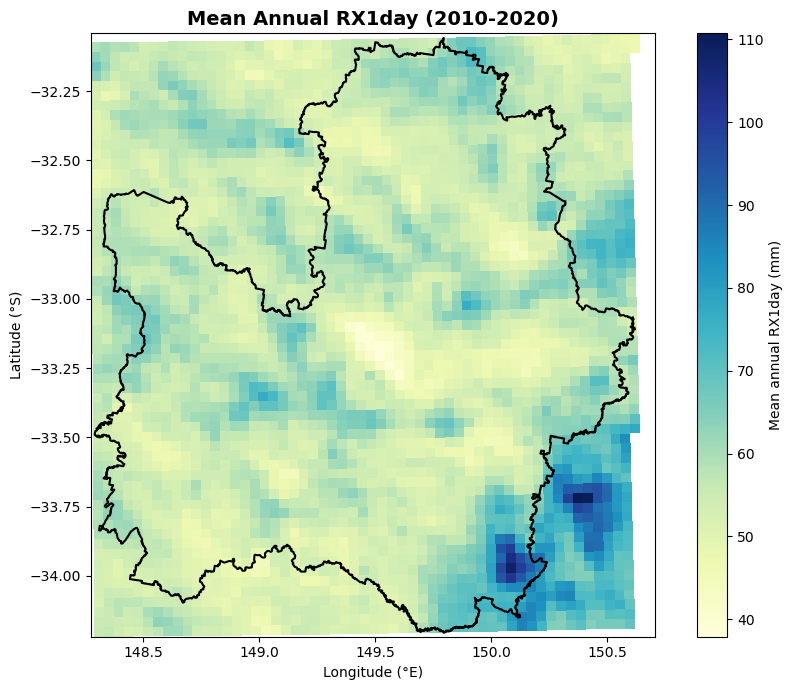

In [29]:
# Calculate mean RX1day spatial pattern. What locations experience the largest annual maximum 1-day rainfall?
# Higher values indicate locations where the strongest single-day rainfall events tend to be larger.
#The resulting map shows where extreme daily rainfall is typically stronger or weaker.
mean_rx1day = rx1day.mean(dim="time",skipna=True)

mean_rx1day.name = "mean_RX1day"
mean_rx1day.attrs["units"] = "mm"

fig, ax = plt.subplots(figsize=(9, 7))

mean_rx1day.plot(ax=ax, x="lon", y="lat", cmap="YlGnBu", cbar_kwargs={"label": "Mean annual RX1day (mm)"})

central_tablelands.boundary.plot(ax=ax,edgecolor="black",linewidth=1.5)

start_year = int(rx1day.time.dt.year.min())
end_year = int(rx1day.time.dt.year.max())

ax.set_title(f"Mean Annual RX1day ({start_year}-{end_year})",fontsize=14,fontweight="bold")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")

plt.tight_layout()
plt.show()

<xarray.DataArray 'regional_RX1day' (time: 11)> Size: 44B
dask.array<mean_agg-aggregate, shape=(11,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 88B 2010-01-01 2011-01-01 ... 2020-01-01
Attributes:
    units:    mm


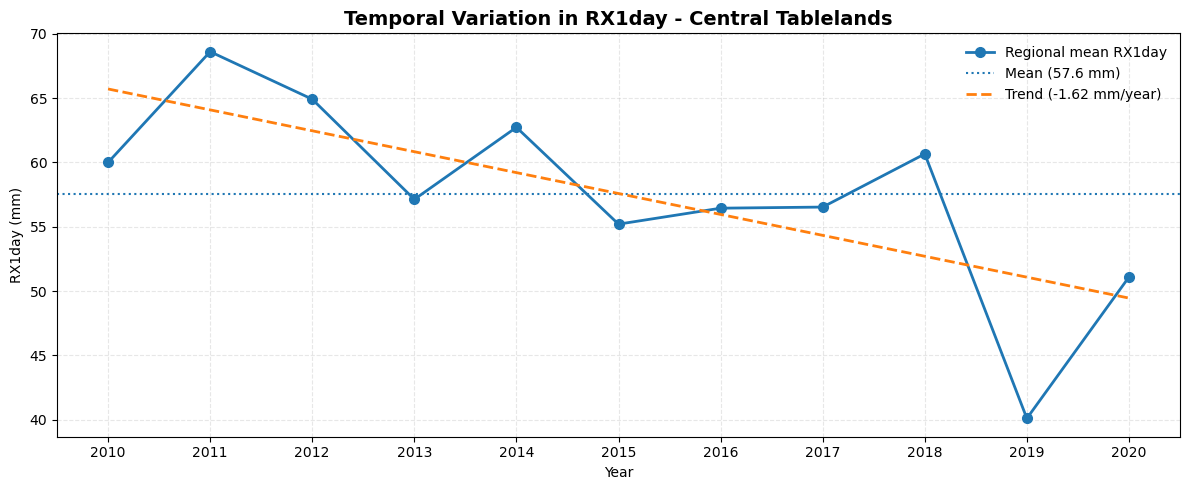

Regional RX1day trend: -1.62 mm/year


In [30]:
# Temporal pattern analysis. Regional mean RX1day for each year
# calculate RX1day at every pixel, then spatially average those annual values. This gives one value per year.

regional_rx1day = rx1day.mean(dim=["rlat", "rlon"],skipna=True)

regional_rx1day.name = "regional_RX1day"
regional_rx1day.attrs["units"] = "mm"

print(regional_rx1day)

# Temporal pattern and linear trend in regional RX1day
years = regional_rx1day.time.dt.year.values
values = regional_rx1day.values

# Linear trend
slope, intercept = np.polyfit(years,values,1)

trend = slope * years + intercept

# Long-term mean
mean_value = float(regional_rx1day.mean().compute())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

# Annual regional RX1day
ax.plot(years,values,marker="o",markersize=7,linewidth=2,label="Regional mean RX1day")

# Long-term mean
ax.axhline(mean_value,linestyle=":",linewidth=1.5,label=f"Mean ({mean_value:.1f} mm)")

# Linear trend
ax.plot(years,trend,linestyle="--",linewidth=2,label=f"Trend ({slope:.2f} mm/year)")

ax.set_title("Temporal Variation in RX1day - Central Tablelands",fontsize=14,fontweight="bold")

ax.set_xlabel("Year")
ax.set_ylabel("RX1day (mm)")

ax.set_xticks(years)

ax.grid(True,linestyle="--",alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Regional RX1day trend: {slope:.2f} mm/year")

In [31]:
# Spatial trend analysis. Calculate RX1day trend at every grid cell
# As rx1day is Dask-backed, rechunk the annual time dimension first

# Keep all years in one Dask time chunk
rx1day_trend_input = rx1day.chunk({"time": -1})

# Numeric years
years = (rx1day_trend_input.time.dt.year.values.astype(float))

# Function to calculate slope
def calculate_trend(y):
    valid = np.isfinite(y)
    if valid.sum() < 3:
        return np.nan
    slope, _, _, _, _ = linregress(
        years[valid],
        y[valid]
    )
    return slope

# Apply to every grid cell
rx1day_trend = xr.apply_ufunc(calculate_trend, rx1day_trend_input, input_core_dims=[["time"]], output_core_dims=[[]], vectorize=True,
                              dask="parallelized", output_dtypes=[float])

# Compute result
rx1day_trend = rx1day_trend.compute()

# Metadata
rx1day_trend.name = "RX1day_trend"
rx1day_trend.attrs["units"] = "mm/year"
rx1day_trend.attrs["long_name"] = ("Linear trend in annual maximum 1-day precipitation")

print(rx1day_trend)

<xarray.DataArray 'RX1day_trend' (rlat: 61, rlon: 57)> Size: 28kB
array([[-0.34223744, -0.32117292, -0.04978707, ..., -1.58693338,
                nan,         nan],
       [-0.46981857, -0.37681462, -0.6192189 , ..., -0.47555917,
                nan,         nan],
       [-0.30738695, -0.46188247, -1.10037134, ..., -2.71395264,
                nan,         nan],
       ...,
       [-4.3794744 , -3.18081825, -1.60968246, ..., -0.01141163,
        -0.34203266,         nan],
       [-4.46070727, -2.77167119, -1.72985167, ..., -0.21756678,
        -1.08915003, -0.86014512],
       [-2.17758806, -1.75610792, -1.79124537, ..., -0.73603779,
        -1.39959027, -1.69183523]], shape=(61, 57))
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
    lat      (rlat, rlon) float64 28kB -34.2 -34.2 -34.2 ... -32.06 -32.06
    lon      (rlat, rlon) float64 28kB 148.3 148.4 148.4 ..

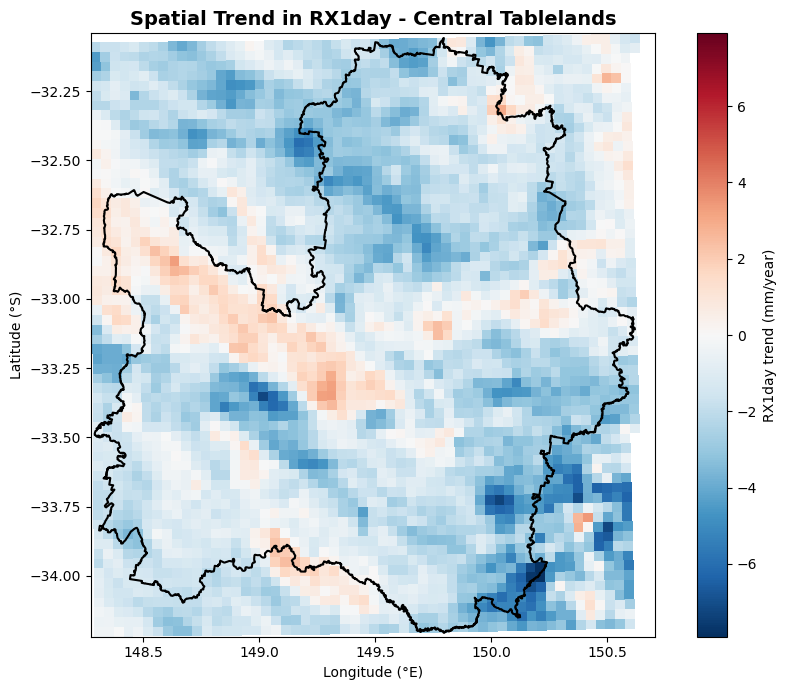

In [32]:
# 7. Plot spatial trend in RX1day

fig, ax = plt.subplots(figsize=(9, 7))

rx1day_trend.plot(ax=ax,x="lon",y="lat",cmap="RdBu_r",center=0,cbar_kwargs={"label": "RX1day trend (mm/year)"})

central_tablelands.boundary.plot(ax=ax,edgecolor="black",linewidth=1.5)

ax.set_title("Spatial Trend in RX1day - Central Tablelands",fontsize=14,fontweight="bold")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")

plt.tight_layout()
plt.show()

In [33]:
# RX1day summary statistics

print("======== RX1day SUMMARY ========")
print("\nStudy period:", f"{int(rx1day.time.dt.year.min())}-{int(rx1day.time.dt.year.max())}")

print("\nMean regional RX1day:", f"{float(regional_rx1day.mean().compute()):.2f} mm")

max_index = int(regional_rx1day.argmax().compute())

print("\nHighest regional mean RX1day:", f"{float(regional_rx1day.isel(time=max_index)):.2f} mm in {int(regional_rx1day.time.dt.year.isel(time=max_index))}")

min_index = int(regional_rx1day.argmin().compute())

print("\nLowest regional mean RX1day:", f"{float(regional_rx1day.isel(time=min_index)):.2f} mm in {int(regional_rx1day.time.dt.year.isel(time=min_index))}")

print("\nRegional linear trend:", f"{slope:.2f} mm/year")

======== RX1day SUMMARY ========

Study period: 2010-2020

Mean regional RX1day: 57.59 mm

Highest regional mean RX1day: 68.61 mm in 2011

Lowest regional mean RX1day: 40.11 mm in 2019

Regional linear trend: -1.62 mm/year


In [34]:
# Calculate monthly RX1day at every grid cell
# Monthly RX1day:Maximum 1-day precipitation within each month
rx1day_monthly = pr_ready.resample(time="MS").max(dim="time",skipna=True)

# Metadata
rx1day_monthly.name = "RX1day_monthly"
rx1day_monthly.attrs["units"] = "mm"
rx1day_monthly.attrs["long_name"] = ("Monthly maximum 1-day precipitation")

print(rx1day_monthly)

print("\nDimensions:")
print(rx1day_monthly.sizes)

print("\nTime period:")
print(rx1day_monthly.time.min().values,"to",rx1day_monthly.time.max().values)

<xarray.DataArray 'RX1day_monthly' (time: 132, rlat: 61, rlon: 57)> Size: 2MB
dask.array<stack, shape=(132, 61, 57), dtype=float32, chunksize=(1, 61, 57), chunktype=numpy.ndarray>
Coordinates:
  * rlon     (rlon) float64 456B 170.5 170.5 170.5 170.6 ... 172.4 172.4 172.4
  * rlat     (rlat) float64 488B -4.514 -4.479 -4.444 ... -2.472 -2.437 -2.402
    lat      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
    lon      (rlat, rlon) float64 28kB dask.array<chunksize=(61, 57), meta=np.ndarray>
  * time     (time) datetime64[ns] 1kB 2010-01-01 2010-02-01 ... 2020-12-01
Attributes:
    units:              mm
    long_name:          Monthly maximum 1-day precipitation
    region:             Central Tablelands
    period:             2010-2020
    spatial_selection:  Grid-cell centres within the region bounding box

Dimensions:
Frozen({'time': 132, 'rlat': 61, 'rlon': 57})

Time period:
2010-01-01T00:00:00.000000000 to 2020-12-01T00:00:00.000000000


C:\Users\146761\.conda\envs\gee1\lib\site-packages\dask\array\reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
C:\Users\146761\.conda\envs\gee1\lib\site-packages\dask\array\reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
C:\Users\146761\.conda\envs\gee1\lib\site-packages\dask\array\reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
C:\Users\146761\.conda\envs\gee1\lib\site-packages\dask\array\reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


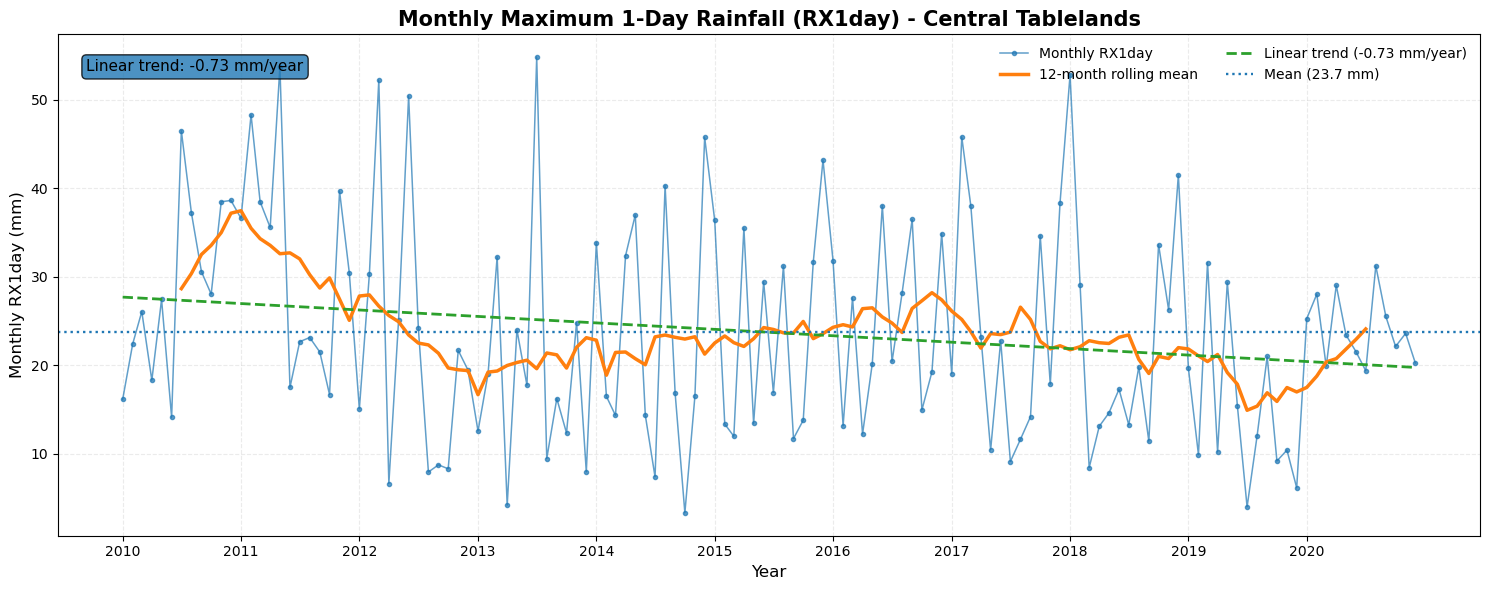

In [35]:
# Regional mean monthly RX1day
regional_rx1day_monthly = rx1day_monthly.mean(dim=["rlat", "rlon"],skipna=True)

regional_rx1day_monthly.name = "regional_monthly_RX1day"
regional_rx1day_monthly.attrs["units"] = "mm"

# Calculate 12-month rolling mean
rx1day_rolling = regional_rx1day_monthly.rolling(time=12,center=True).mean()

# Calculate long-term mean
long_term_mean = float(regional_rx1day_monthly.mean().compute())

# Calculate linear trend
values = regional_rx1day_monthly.values
x = np.arange(len(values))

valid = np.isfinite(values)

slope, intercept = np.polyfit(x[valid],values[valid],1)

trend = slope * x + intercept

# Convert monthly slope to approximate mm/year
trend_per_year = slope * 12

# Plot monthly RX1day
fig, ax = plt.subplots(figsize=(15, 6))

# Monthly RX1day
ax.plot(regional_rx1day_monthly.time.values,values,linewidth=1.1,marker="o",markersize=3,alpha=0.7,label="Monthly RX1day")

# 12-month rolling mean
ax.plot(rx1day_rolling.time.values,rx1day_rolling.values,linewidth=2.5,label="12-month rolling mean")

# Linear trend
ax.plot(regional_rx1day_monthly.time.values,trend,linestyle="--",linewidth=2,label=f"Linear trend ({trend_per_year:.2f} mm/year)")

# Add trend value inside the plot
ax.text(0.02,0.95,f"Linear trend: {trend_per_year:.2f} mm/year",transform=ax.transAxes,fontsize=11,verticalalignment="top",
        bbox=dict(boxstyle="round",alpha=0.8))

# Long-term mean
ax.axhline(long_term_mean,linestyle=":",linewidth=1.7,label=f"Mean ({long_term_mean:.1f} mm)")

# x-axis labels
# Show one tick per year
year_ticks = regional_rx1day_monthly.time.where(regional_rx1day_monthly.time.dt.month == 1,drop=True)

ax.set_xticks(year_ticks.values)

ax.set_xticklabels(year_ticks.time.dt.year.values,rotation=0)

# Figure formatting
ax.set_title("Monthly Maximum 1-Day Rainfall (RX1day) - Central Tablelands",fontsize=15,fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Monthly RX1day (mm)", fontsize=12)

ax.grid(True,linestyle="--",alpha=0.25)

ax.legend(frameon=False,ncol=2)

plt.tight_layout()
plt.show()

# # Print summary
# print(f"Mean monthly RX1day: {long_term_mean:.2f} mm")
# print(f"Linear trend: {trend_per_year:.2f} mm/year")

<xarray.DataArray 'regional_monthly_RX1day' (month: 12)> Size: 48B
dask.array<stack, shape=(12,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    mm


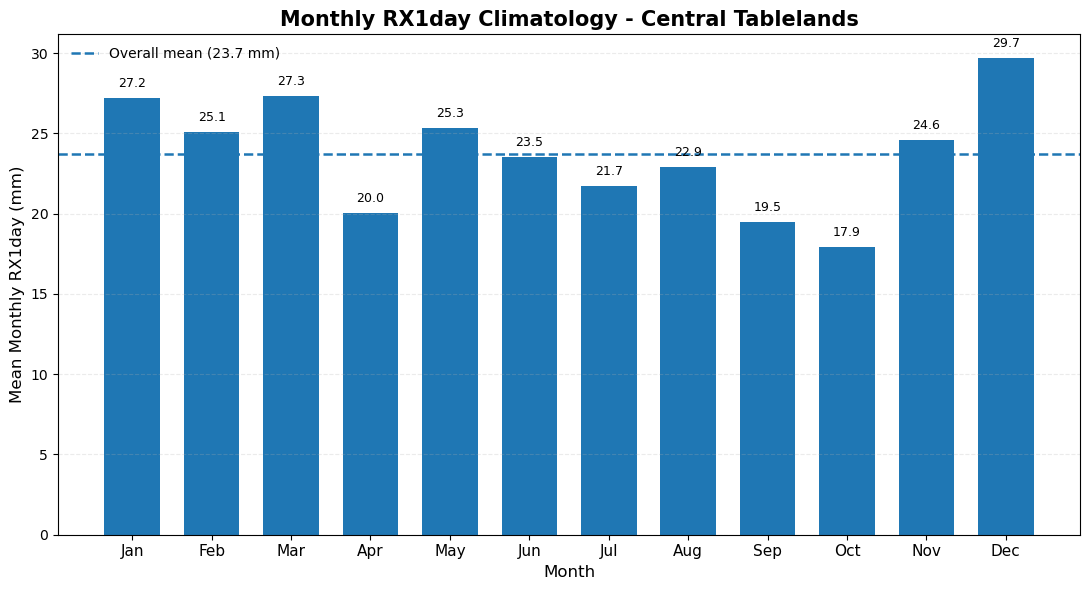

In [36]:
# Monthly RX1day climatology
# Mean RX1day for each calendar month across all years, shwoing which months typically experience the strongest 1-day rainfall extremes.
monthly_rx1day_climatology = (regional_rx1day_monthly.groupby("time.month").mean())

print(monthly_rx1day_climatology)

# Overall mean monthly RX1day
overall_mean = float(regional_rx1day_monthly.mean().compute())

# Plot monthly RX1day climatology
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"]

values = monthly_rx1day_climatology.values

fig, ax = plt.subplots(figsize=(11, 6))

# Bar chart
bars = ax.bar(range(1, 13),values,width=0.7)

# Add overall mean line
ax.axhline(overall_mean,linestyle="--",linewidth=1.8,label=f"Overall mean ({overall_mean:.1f} mm)")

# Add values above bars
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,value + 0.5,f"{value:.1f}",ha="center",va="bottom",fontsize=9)

# X-axis
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names,fontsize=11)

# Titles and labels
ax.set_title("Monthly RX1day Climatology - Central Tablelands",fontsize=15,fontweight="bold")

ax.set_xlabel("Month",fontsize=12)

ax.set_ylabel("Mean Monthly RX1day (mm)",fontsize=12)

# Grid
ax.grid(axis="y",linestyle="--",alpha=0.25)

# Legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

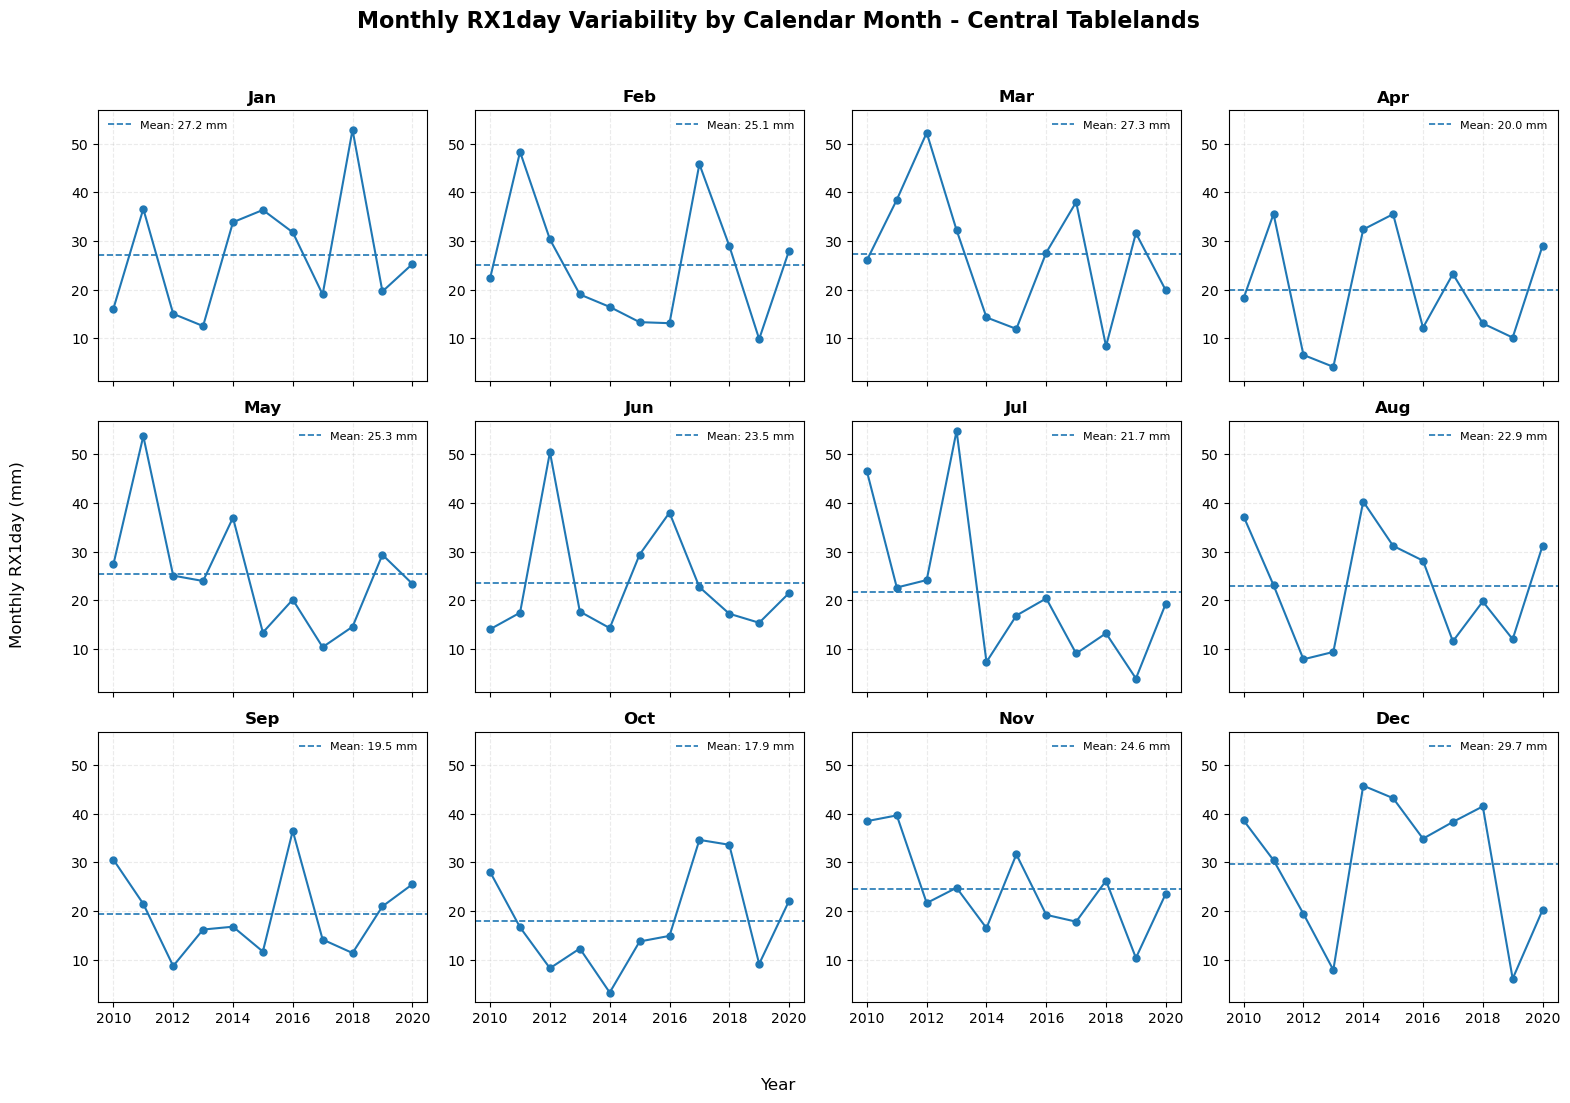

In [39]:
# Monthly RX1day by calendar month
# One subplot for each month across all years

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Remove time steps with NaN regional RX1day values
regional_rx1day_monthly_clean = regional_rx1day_monthly.dropna(dim="time", how="all")

# Create figure
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 11), sharex=True)

# Flatten axes
axes = axes.flatten()

# Use the same y-axis range for all plots
ymin = float(regional_rx1day_monthly_clean.min(skipna=True).compute())
ymax = float(regional_rx1day_monthly_clean.max(skipna=True).compute())

# Plot each calendar month
for month in range(1, 13):

    ax = axes[month - 1]

    # Select calendar month across all years
    data = regional_rx1day_monthly_clean.where(regional_rx1day_monthly_clean.time.dt.month == month, drop=True)

    # Get years and values
    years = data.time.dt.year.values
    values = data.values

    # Plot monthly RX1day through years
    ax.plot(years, values, marker="o", markersize=5, linewidth=1.5)

    # Calculate mean RX1day for the month
    month_mean = float(data.mean(skipna=True).compute())

    # Add monthly mean line
    ax.axhline(month_mean, linestyle="--", linewidth=1.2, label=f"Mean: {month_mean:.1f} mm")

    # Add subplot title
    ax.set_title(month_names[month - 1], fontsize=12, fontweight="bold")

    # Set common y-axis range
    ax.set_ylim(ymin - 2, ymax + 2)

    # Add grid
    ax.grid(True, linestyle="--", alpha=0.25)

    # Add legend
    ax.legend(fontsize=8, frameon=False)

# Add x-axis label
fig.supxlabel("Year", fontsize=12)

# Add y-axis label
fig.supylabel("Monthly RX1day (mm)", fontsize=12)

# Add main title
fig.suptitle("Monthly RX1day Variability by Calendar Month - Central Tablelands", fontsize=16, fontweight="bold", y=0.995)

# Adjust subplot spacing
plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])

# Display plot
plt.show()